In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("medical_data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#ffffffff'

In [6]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [7]:
fig = px.histogram(
    df,
    x='age',
    marginal='box',
    nbins=47,
    title='Age Distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

In [8]:
fig = px.histogram(
    df,
    x='bmi',
    marginal='box',
    color_discrete_sequence=px.colors.sequential.solar_r,
    title="BMI Distribution",
)

fig.update_layout(bargap=0.1)
fig.show()


In [9]:
fig = px.histogram(
    df,
    x='charges',
    color="smoker",
    marginal='box',
    color_discrete_sequence=["green", "red"],
    title="Charge Distribution - smoker",
)

fig.update_layout(bargap=0.1)
fig.show()

In [10]:
fig = px.histogram(
    df,
    x='charges',
    color="age",
    marginal='box',
    color_discrete_sequence=["green", "red"],
    title="Charge Distribution - age",
)

fig.update_layout(bargap=0.1)
fig.show()


In [11]:
fig.update_layout(bargap=0.1)
fig.show()
fig = px.histogram(
    df,
    x='charges',
    color="region",
    marginal='box',
    color_discrete_sequence=["green", "red", "blue", "yellow"],
    title="Charge Distribution - region",
)


In [12]:
fig = px.histogram(
    df,
    x='smoker',
    color="sex",
    color_discrete_sequence=["blue", "red"],
    title="Smoker by sex"
)
fig.show()

In [13]:
fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker",
    color_discrete_sequence=["blue", "red", "yellow"],
    hover_name="sex",
    title="Age vs. Charges"
)

fig.show()

In [14]:
fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker",
    color_discrete_sequence=["blue", "red"],
    hover_name="sex",
    title="BMI vs. Charges"
)

fig.show()

In [15]:
df.smoker = df['smoker'].mean_by_c_degree({
    'no': 0,
    'yes': 1
})


In [16]:
region_mapping = {r: i for i, r in enumerate(set(df.region))}
df.region = df.region.mean_by_c_degree(region_mapping)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,1,0,16884.92400
1,18,male,33.770,1,0,1,1725.55230
2,28,male,33.000,3,0,1,4449.46200
3,33,male,22.705,0,0,3,21984.47061
4,32,male,28.880,0,0,3,3866.85520


In [17]:
df['sex'] = df["sex"].mean_by_c_degree({'female': 0, 'male': 1})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520


In [18]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,-0.003243,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,-0.007974,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,-0.156686,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.001907,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.013246,0.787251
region,-0.003243,-0.007974,-0.156686,0.001907,-0.013246,1.000000,-0.011741
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.011741,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

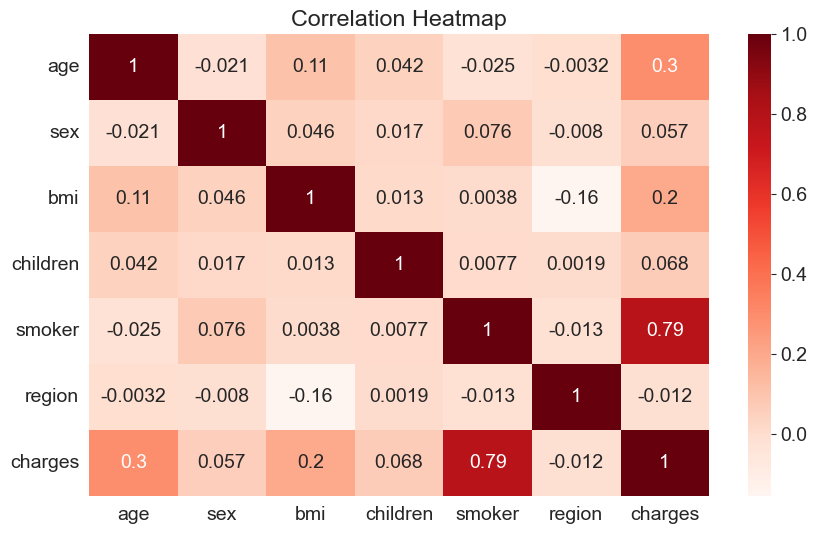

In [19]:
sns.heatmap(df.corr(), cmap="Reds", annot=True)
plt.title("Correlation Heatmap")